In [1]:
import pathlib

import pandas as pd
import numpy as np
import torch

from sklearn.metrics import roc_auc_score, average_precision_score
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from torch_geometric.nn import MessagePassing
from captum.attr import IntegratedGradients, Saliency
from rdkit.Chem import rdMolAlign
from rdkit.Chem import AllChem

from mpnn import visualize_all_activations, AllNonZeroReadout
from highlight_smarts import highlight_atoms_in_mol, visualize_smarts_match
from krfp_models import krfp_models, name_to_post_smarts, name_to_pre_smarts
from mpnn import one_hot_encode, smiles_to_torch, mol_to_torch, MoleculeGDetector
from datavis import visualize_atom_importance, visualize_atom_importance_from_mol
from mpnn.mpnn_arch import AllNonZeroMaxReadout, AllNonZeroSumReadout

from xai_methods import IGAttributionMethod, SaliencyAttributionMethod
from xai_methods.captum_attributions import ShapleyValueSamplingAttributionMethod
from notebook_utils import get_ig_gradient_paths

/home/dominik/MyStuff/bxaic2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "artifacts/explainability_method_tester/R2/MoleculeGDetector/positive_explainability_results.csv")

df = df.dropna(subset=["Integrated Gradients_auroc"])

sus_df = df[df["Integrated Gradients_auroc"] != 1.0]
suspicious_smiles = sus_df["SMILES"].tolist()

suspicious_without_nitrogen_ion = [smiles if "N+" not in smiles else None for smiles in suspicious_smiles]
suspicious_without_nitrogen_ion = [smiles for smiles in suspicious_without_nitrogen_ion if smiles is not None]

print(f"Number of suspicious molecules: {len(suspicious_smiles)}")
print(f"Number of suspicious molecules w/o nitrogen ion: {len(suspicious_without_nitrogen_ion)}")

not_sus_df = df[df["Integrated Gradients_auroc"] == 1.0]
not_sus_smiles = not_sus_df["SMILES"].tolist()

Number of suspicious molecules: 173
Number of suspicious molecules w/o nitrogen ion: 0


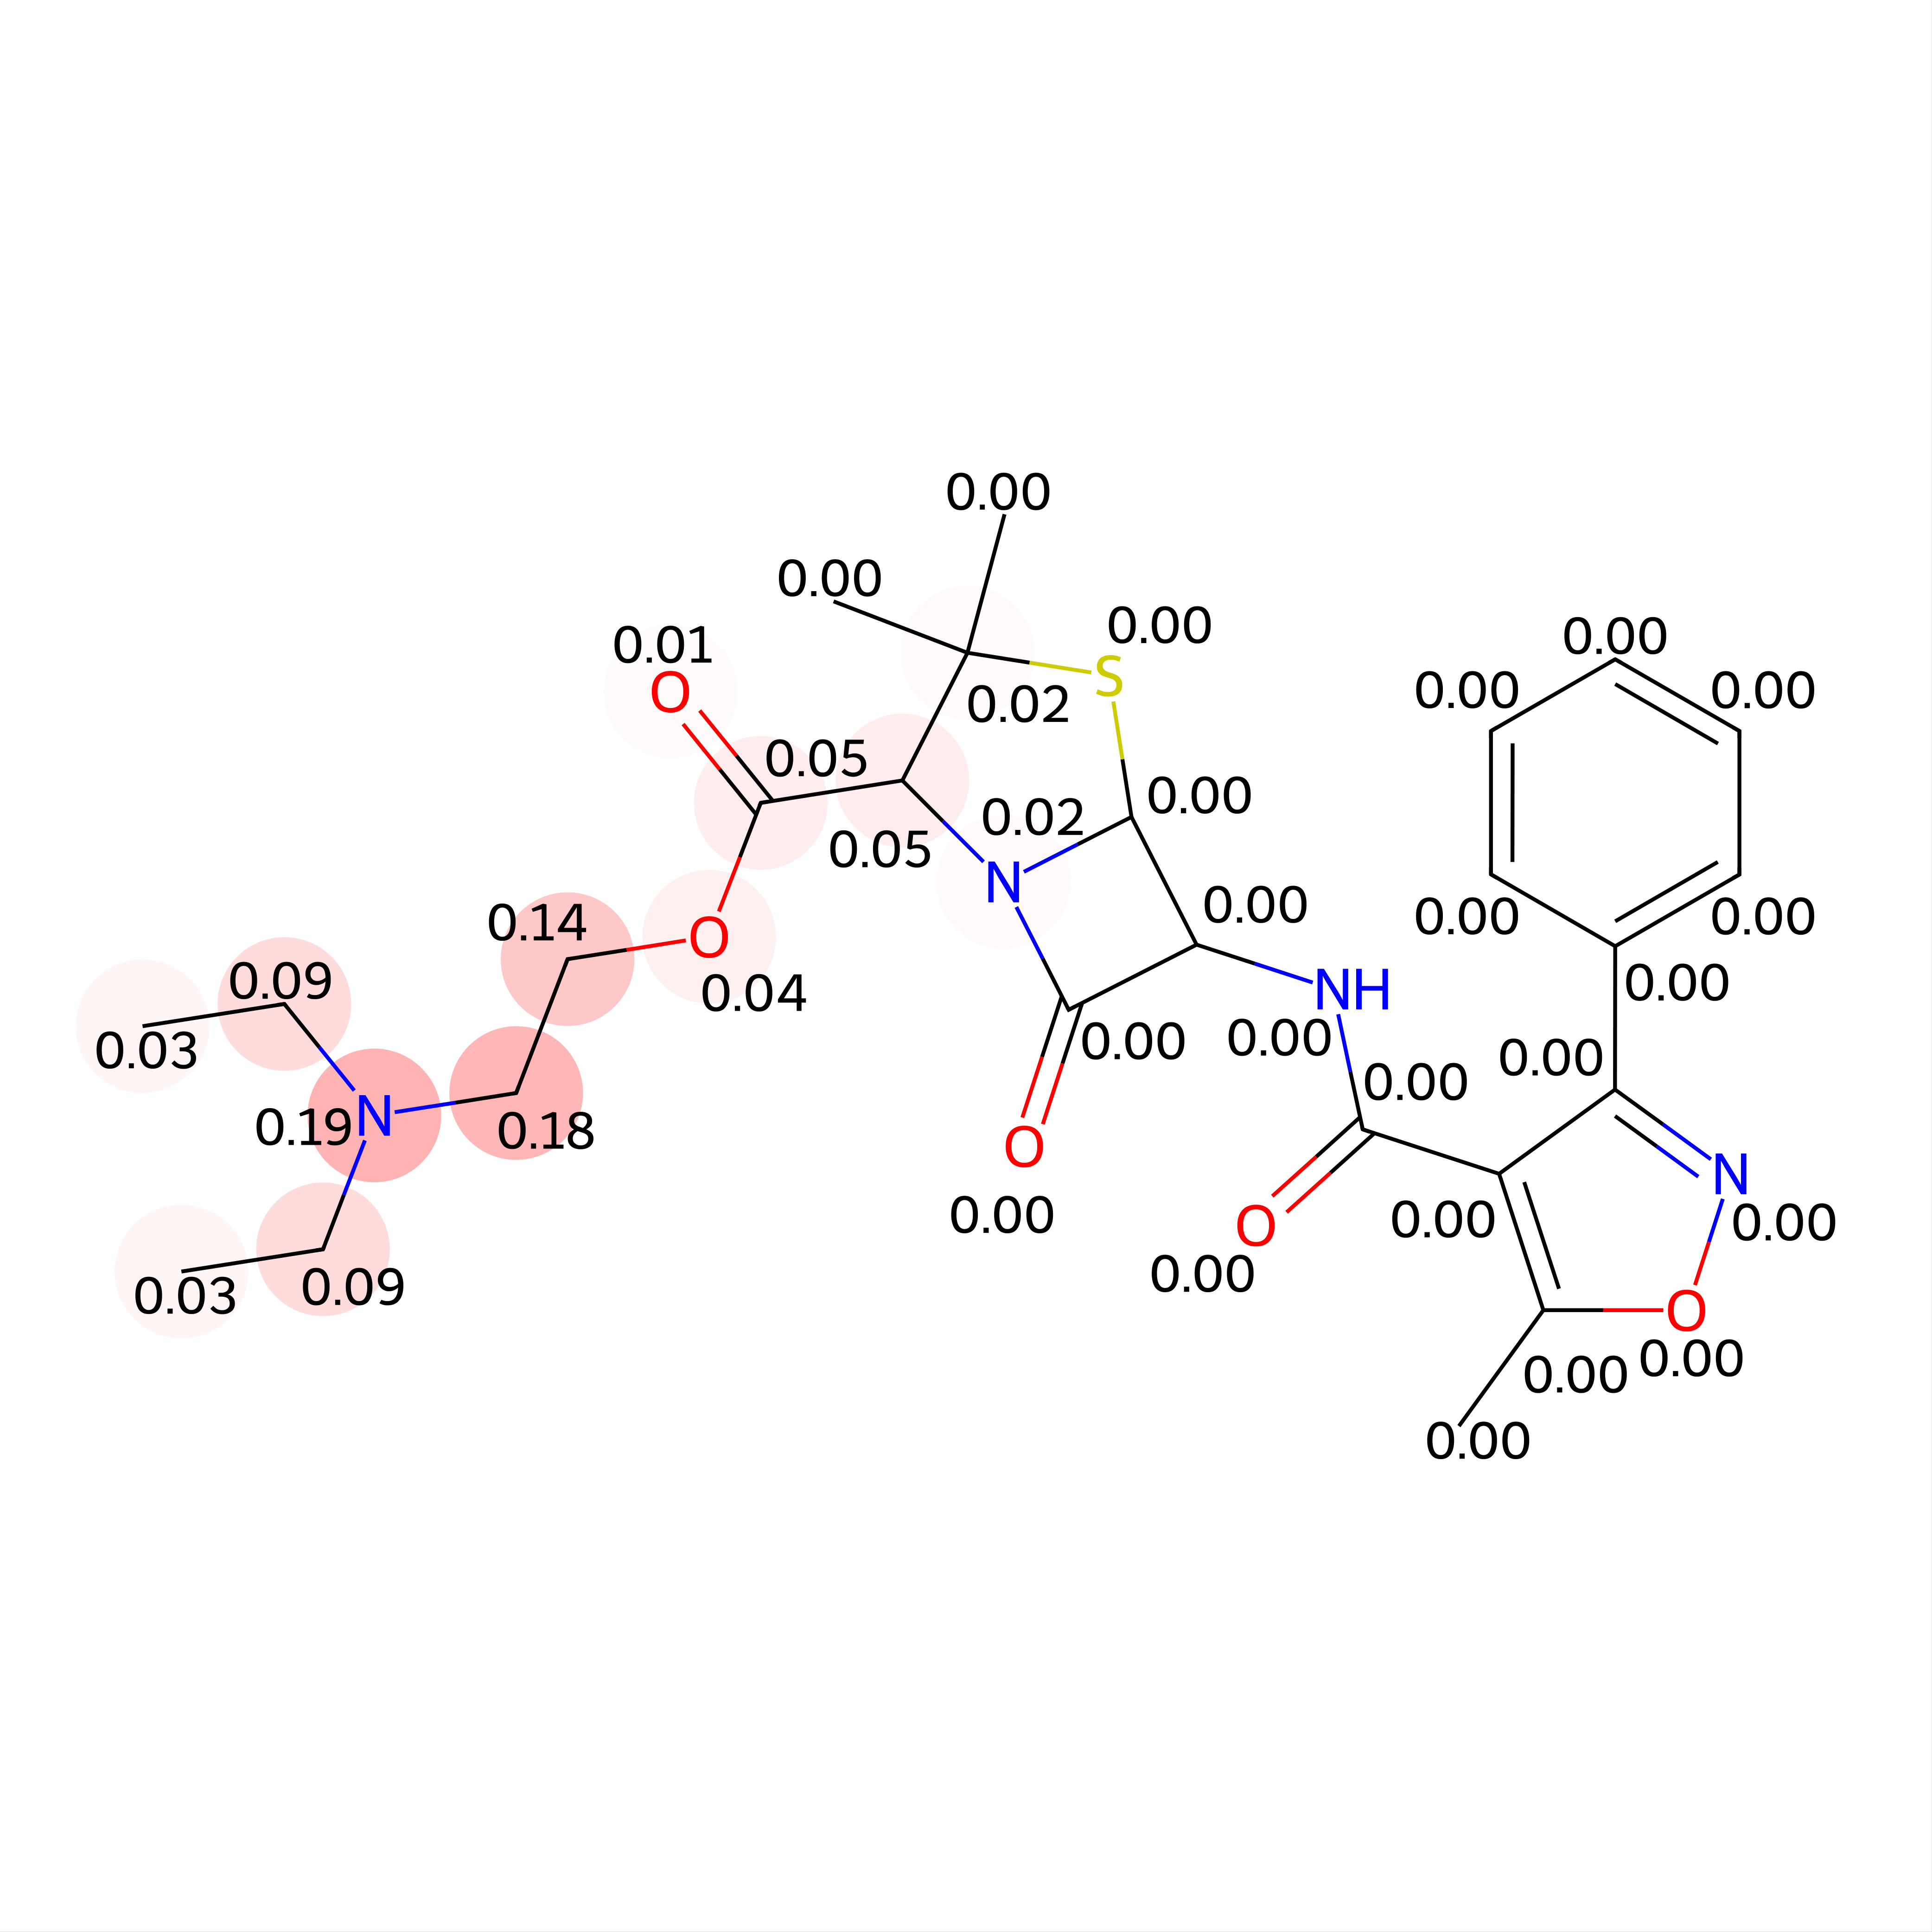

In [3]:
# Here's an example of attribution that worked.

model = MoleculeGDetector()

example_not_suspicious_smile = not_sus_smiles[0]
mol = Chem.MolFromSmiles(example_not_suspicious_smile)
mol = Chem.RemoveAllHs(mol)
x_ok, edge_index_ok, edge_features_ok = mol_to_torch(mol)

smarts_post = name_to_post_smarts["MoleculeGDetector"]

ig_explainer = IGAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = ig_explainer.explain(x_ok, edge_features_ok, edge_index_ok)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000
)

img

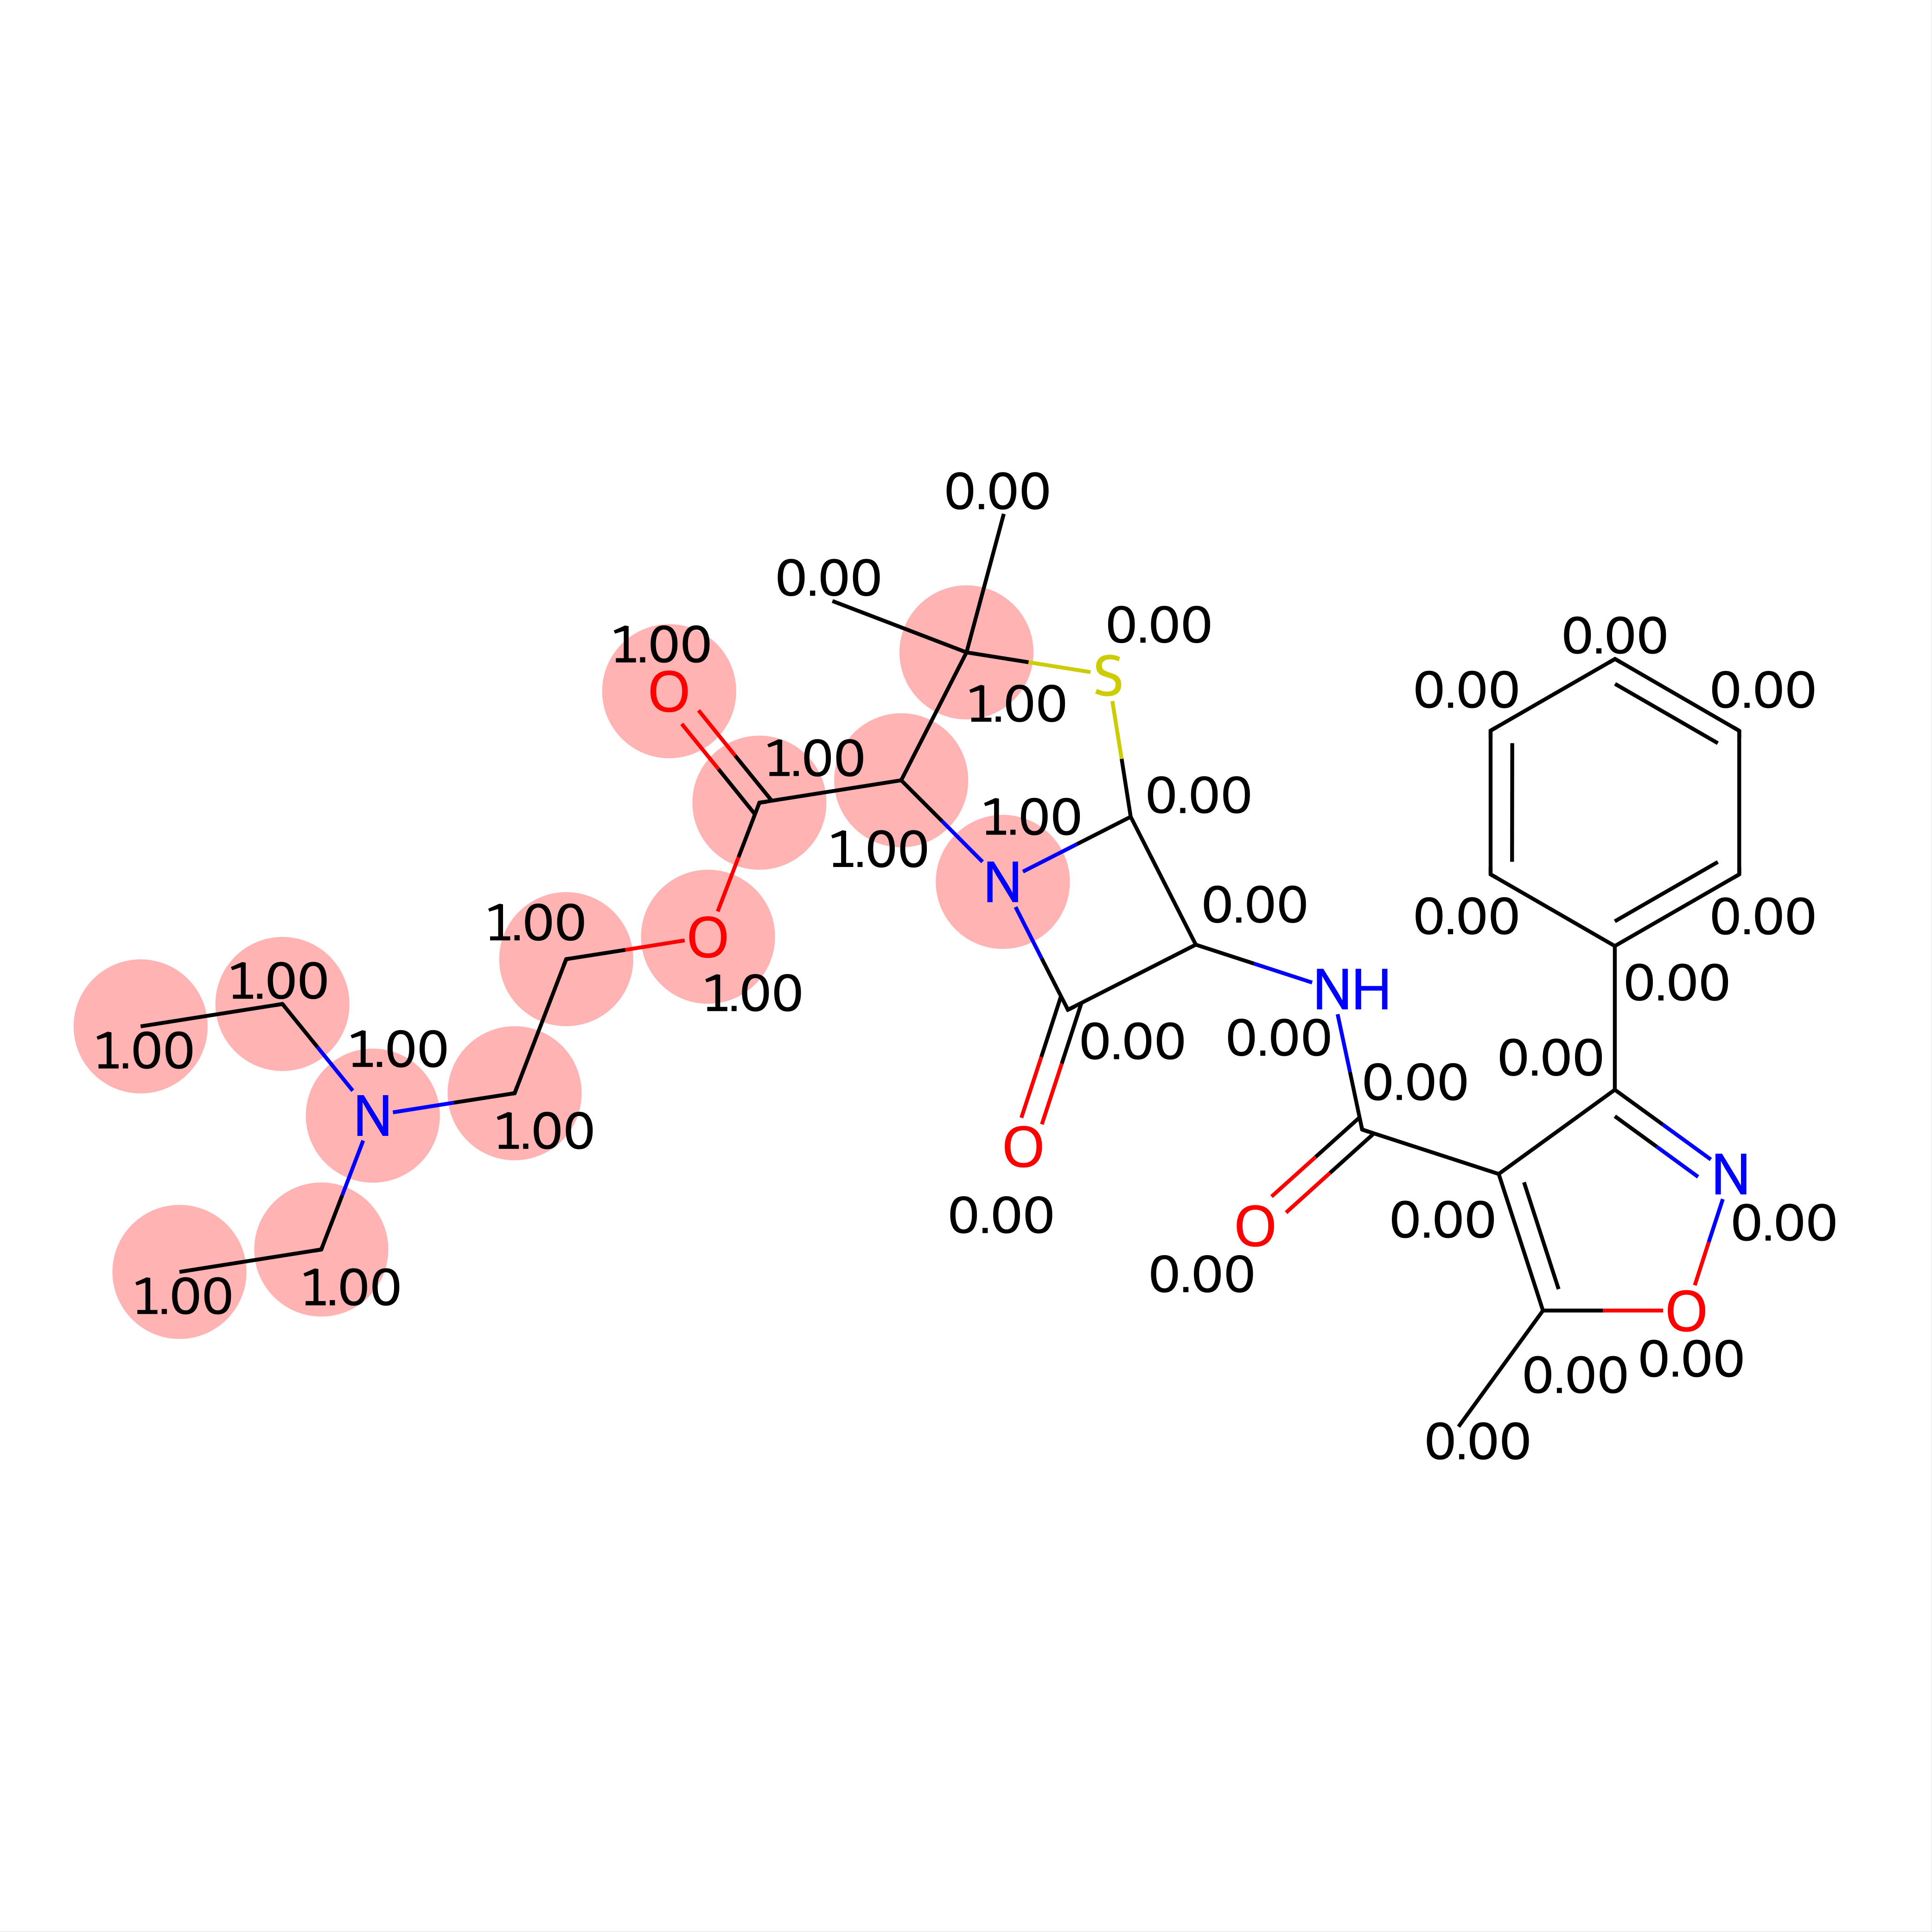

In [4]:
baseline_img = visualize_smarts_match(
    mol,
    smarts_post,
)

baseline_img


In [5]:
model = MoleculeGDetector()

example_suspicious_smile = suspicious_smiles[0]

mol = Chem.MolFromSmiles(example_suspicious_smile)
mol = Chem.RemoveAllHs(mol)
x, edge_index, edge_features = mol_to_torch(mol)

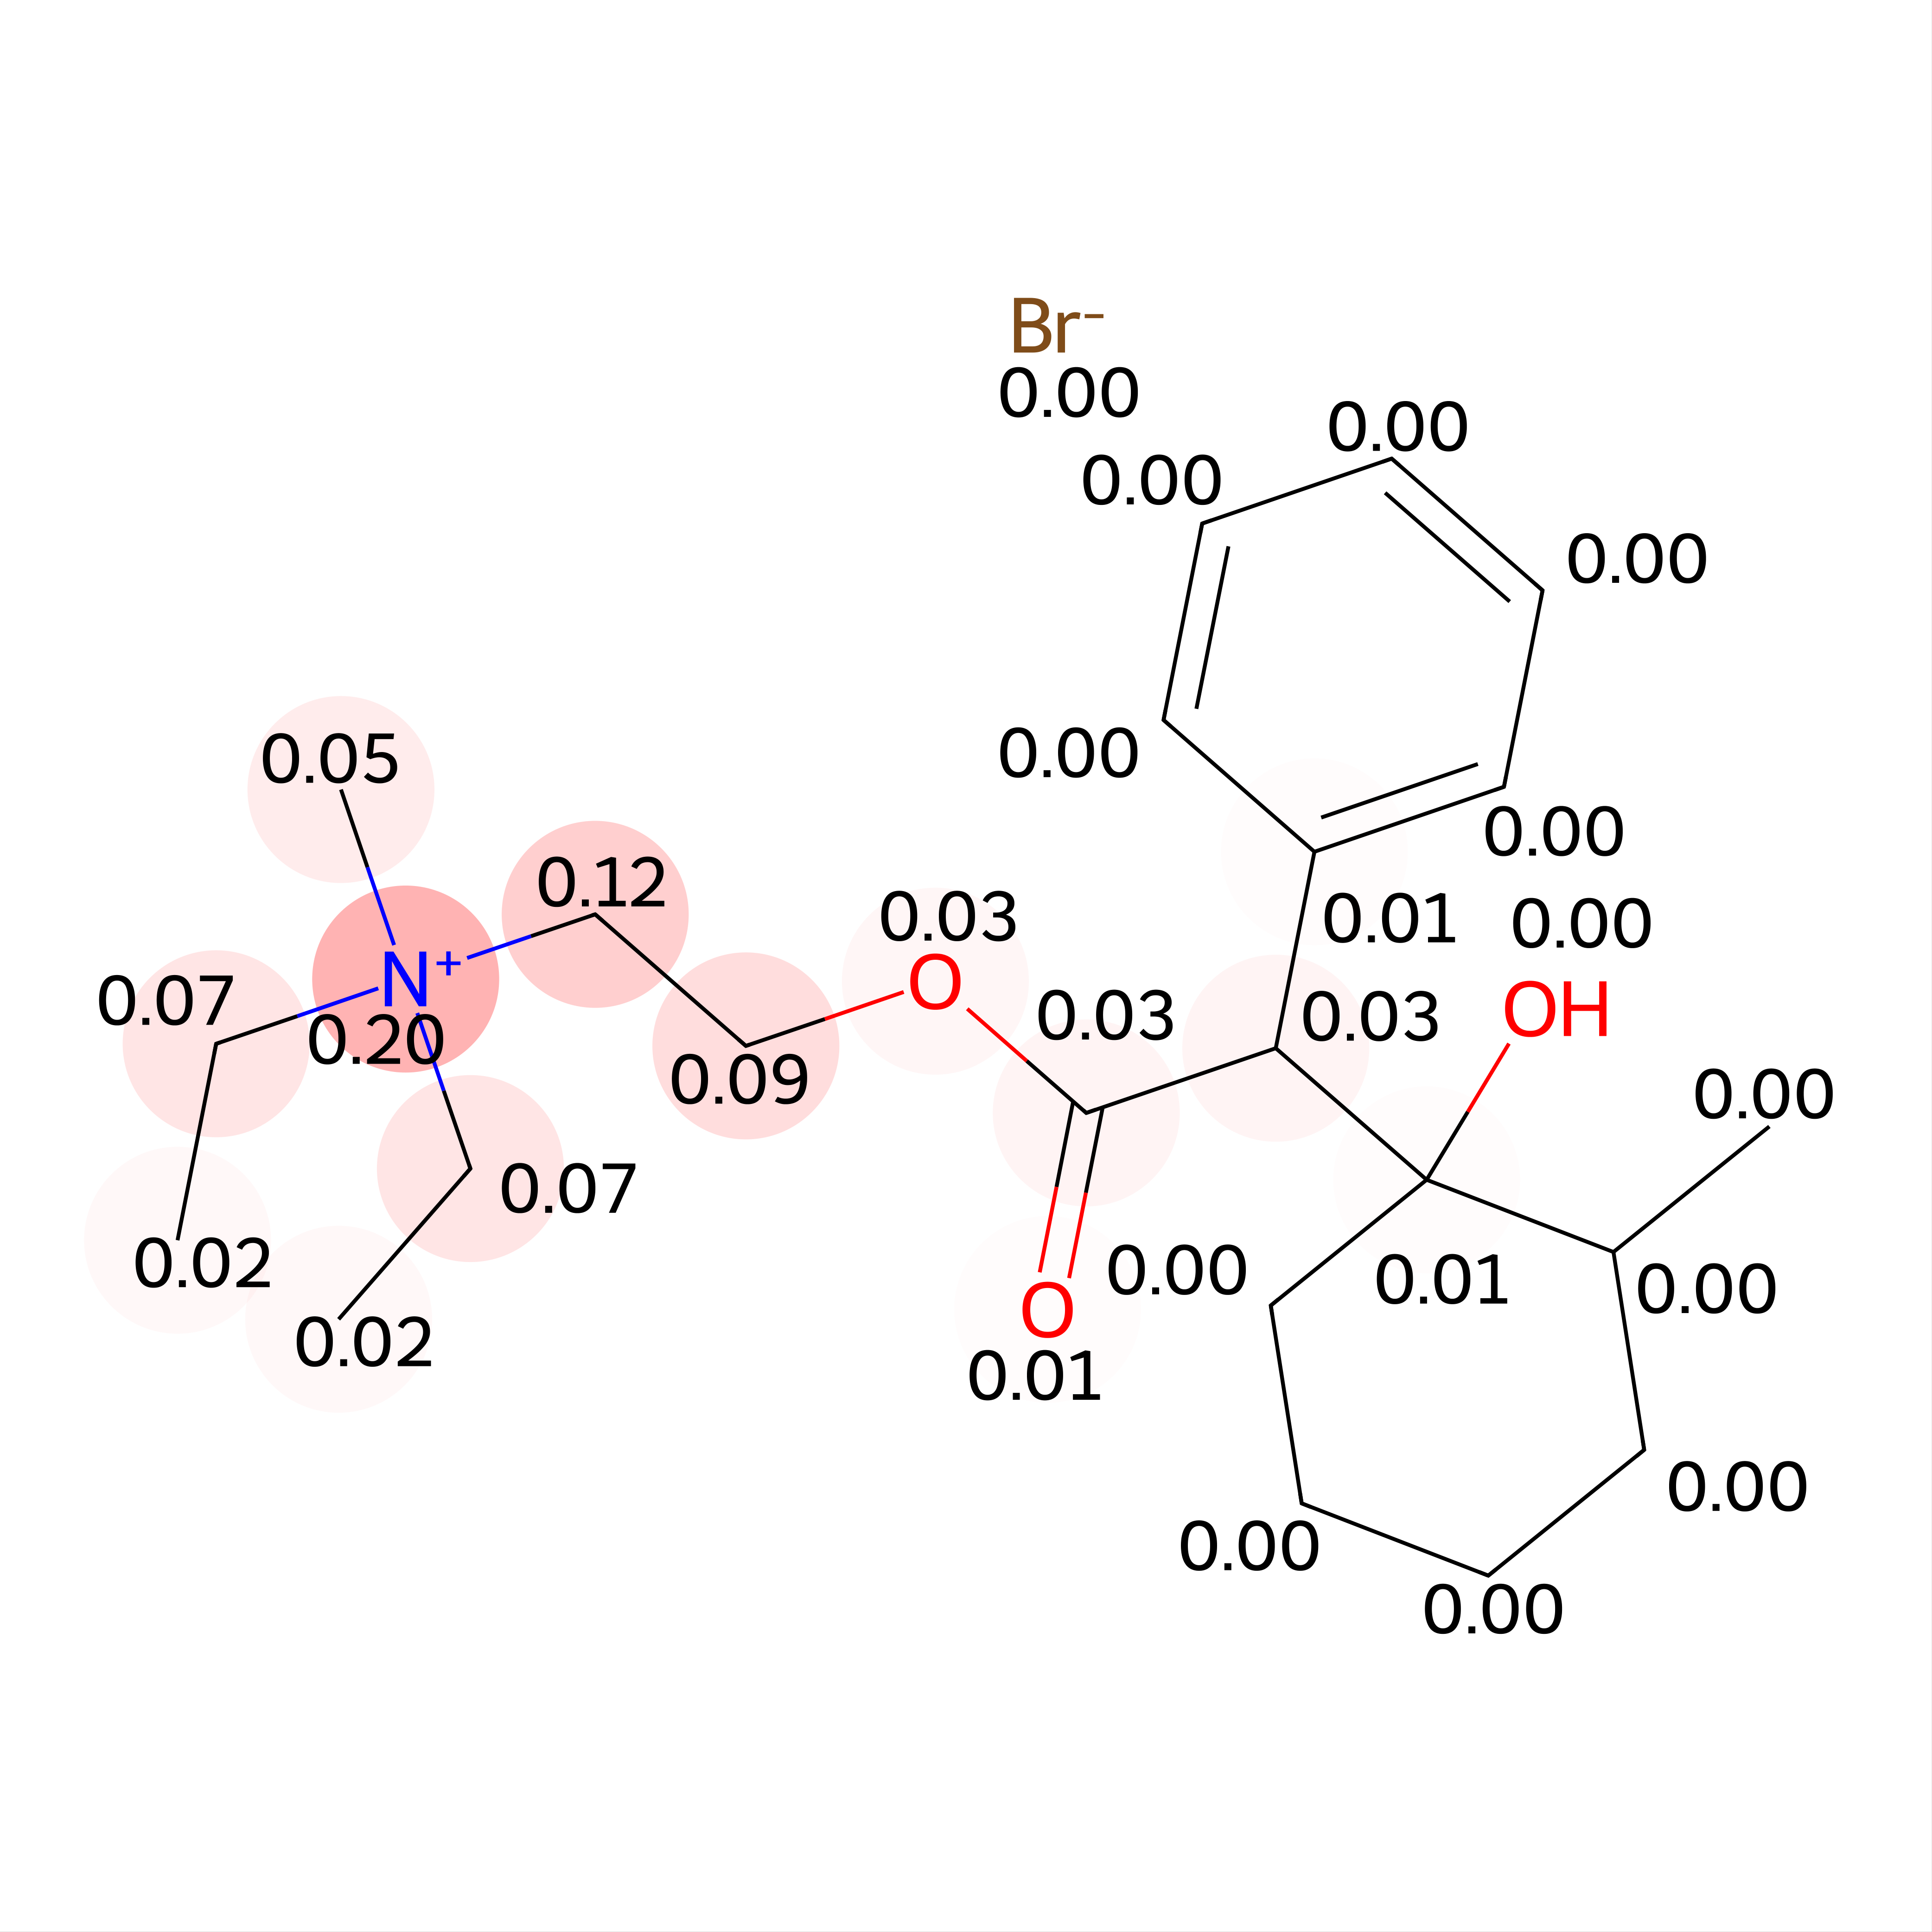

In [6]:
smarts_post = name_to_post_smarts["MoleculeGDetector"]

ig_explainer = IGAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = ig_explainer.explain(x, edge_features, edge_index)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000,
)

img

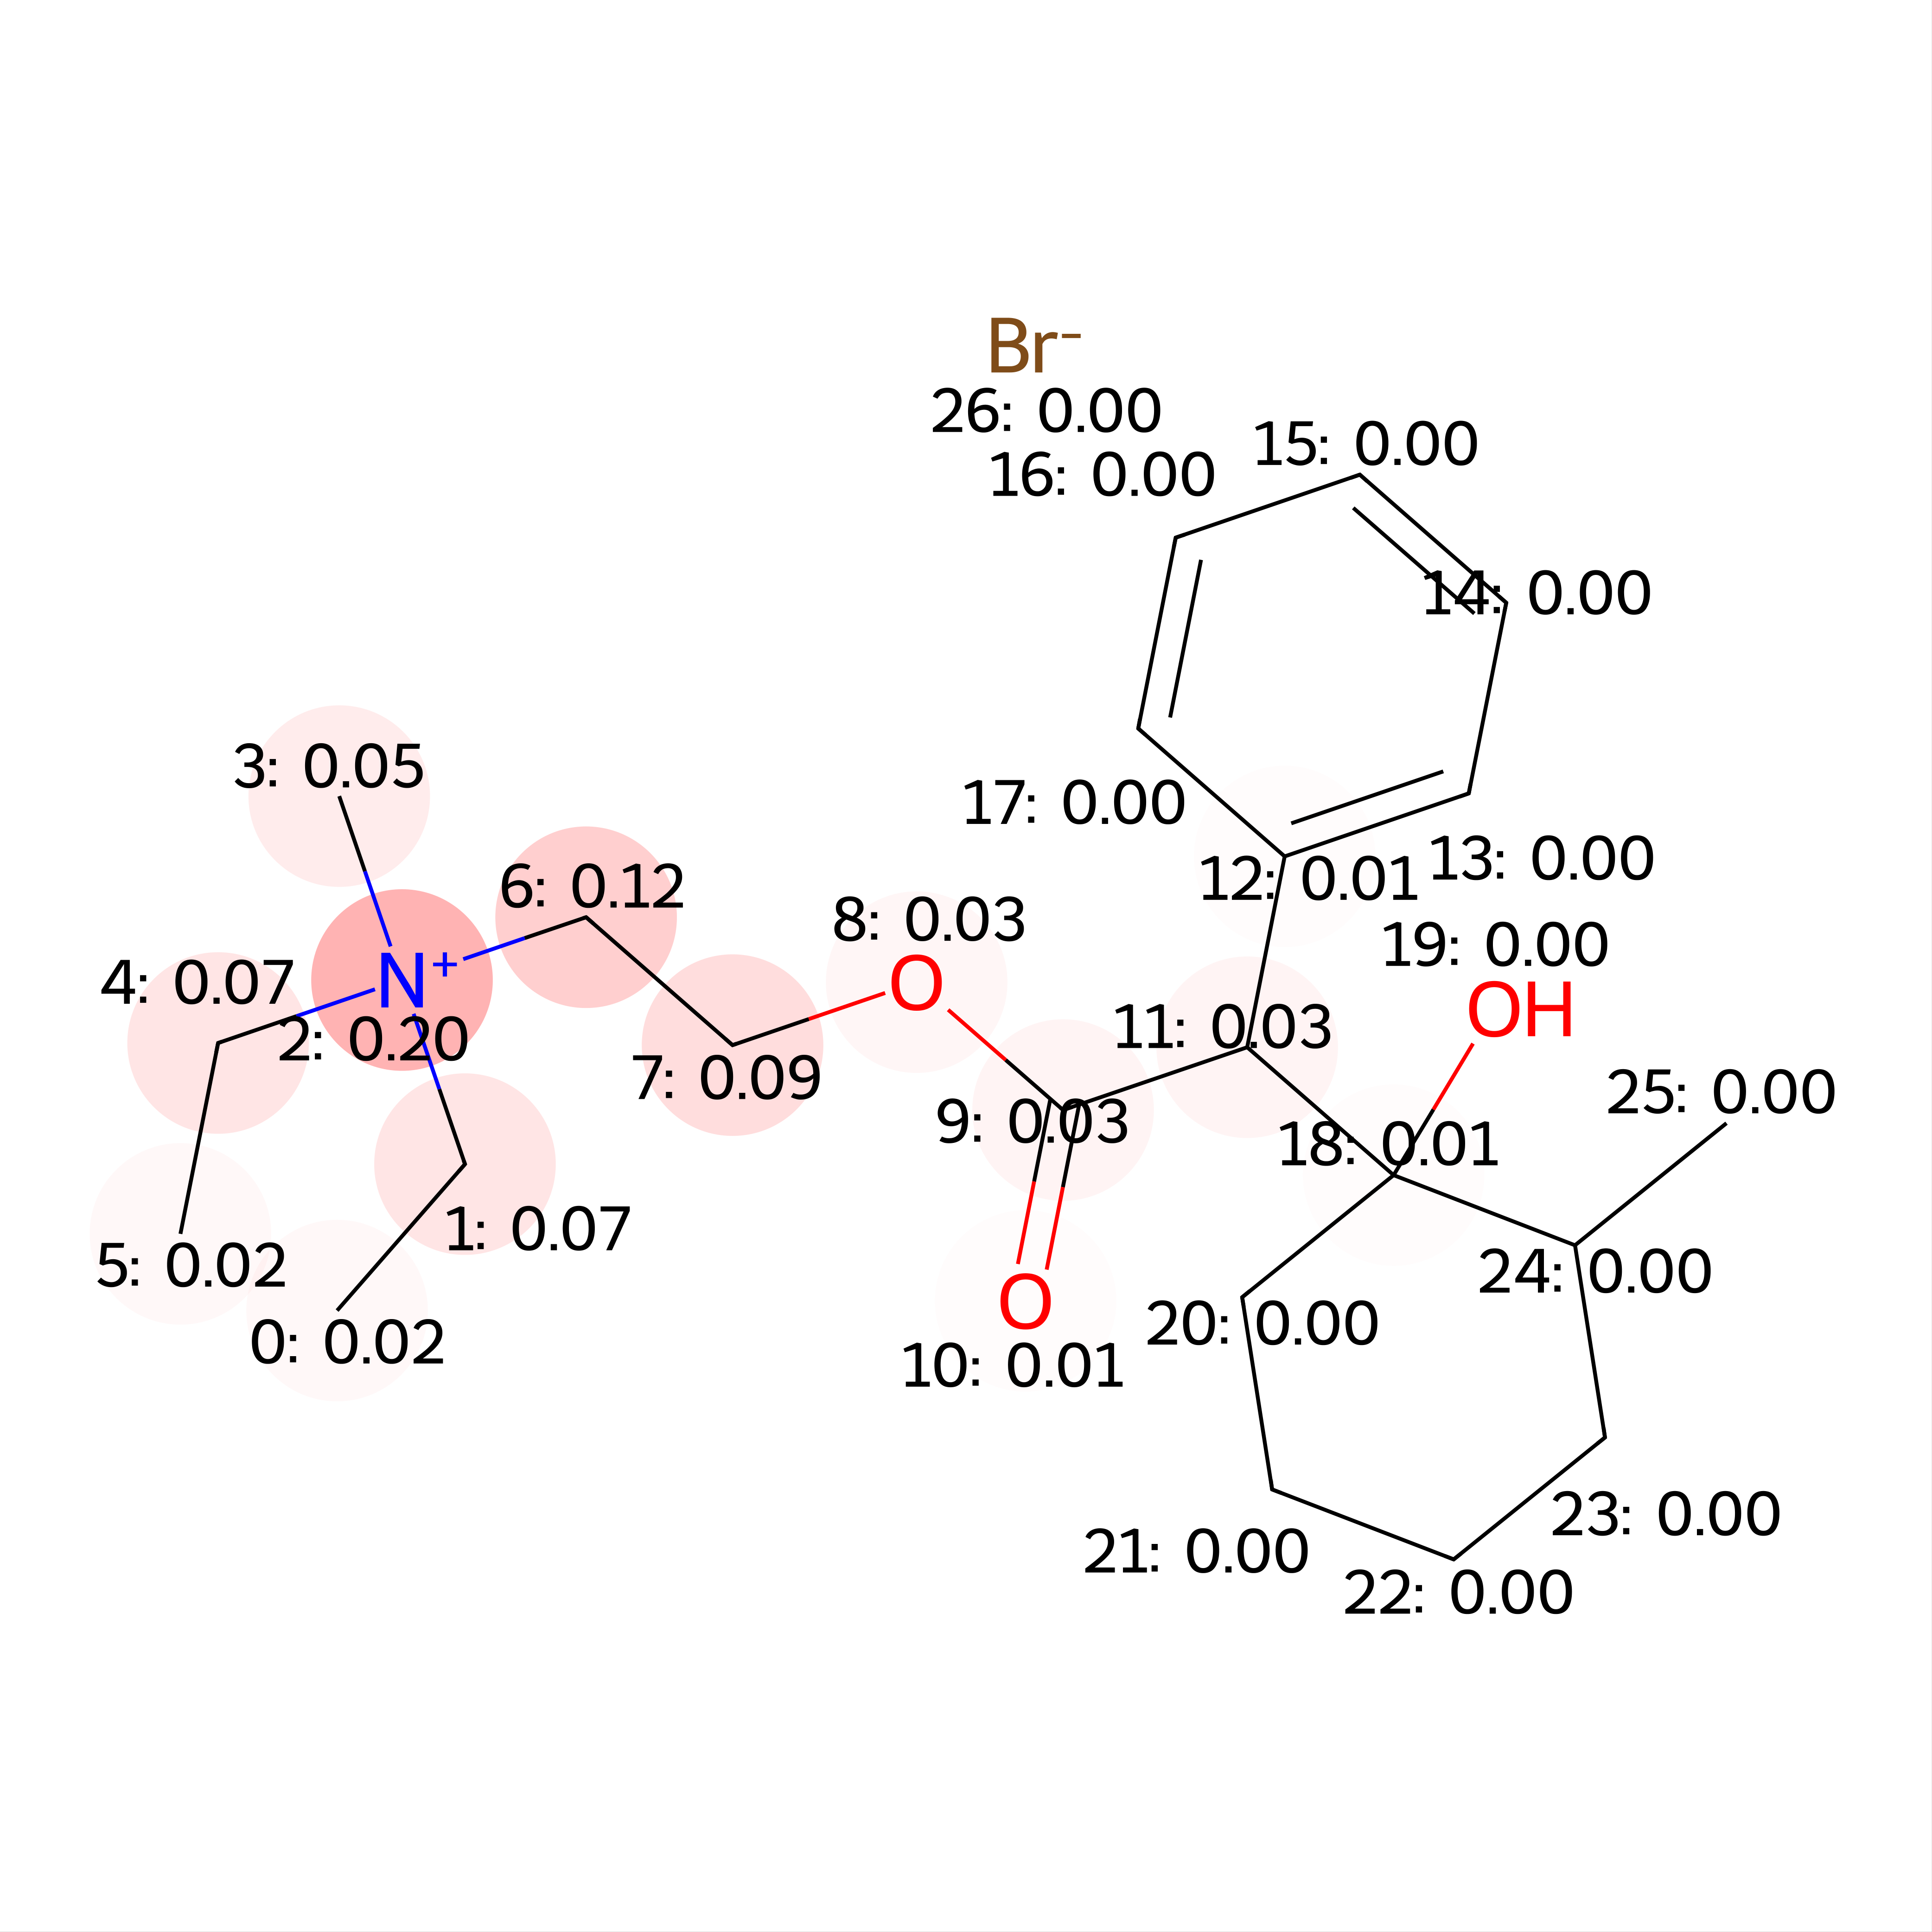

In [7]:
# For appendix: Node ids + attributions
smarts_post = name_to_post_smarts["MoleculeGDetector"]

ig_explainer = IGAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = ig_explainer.explain(x, edge_features, edge_index)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000,
    show_atom_idx=True,
    annotation_font_scale=0.8
)

img

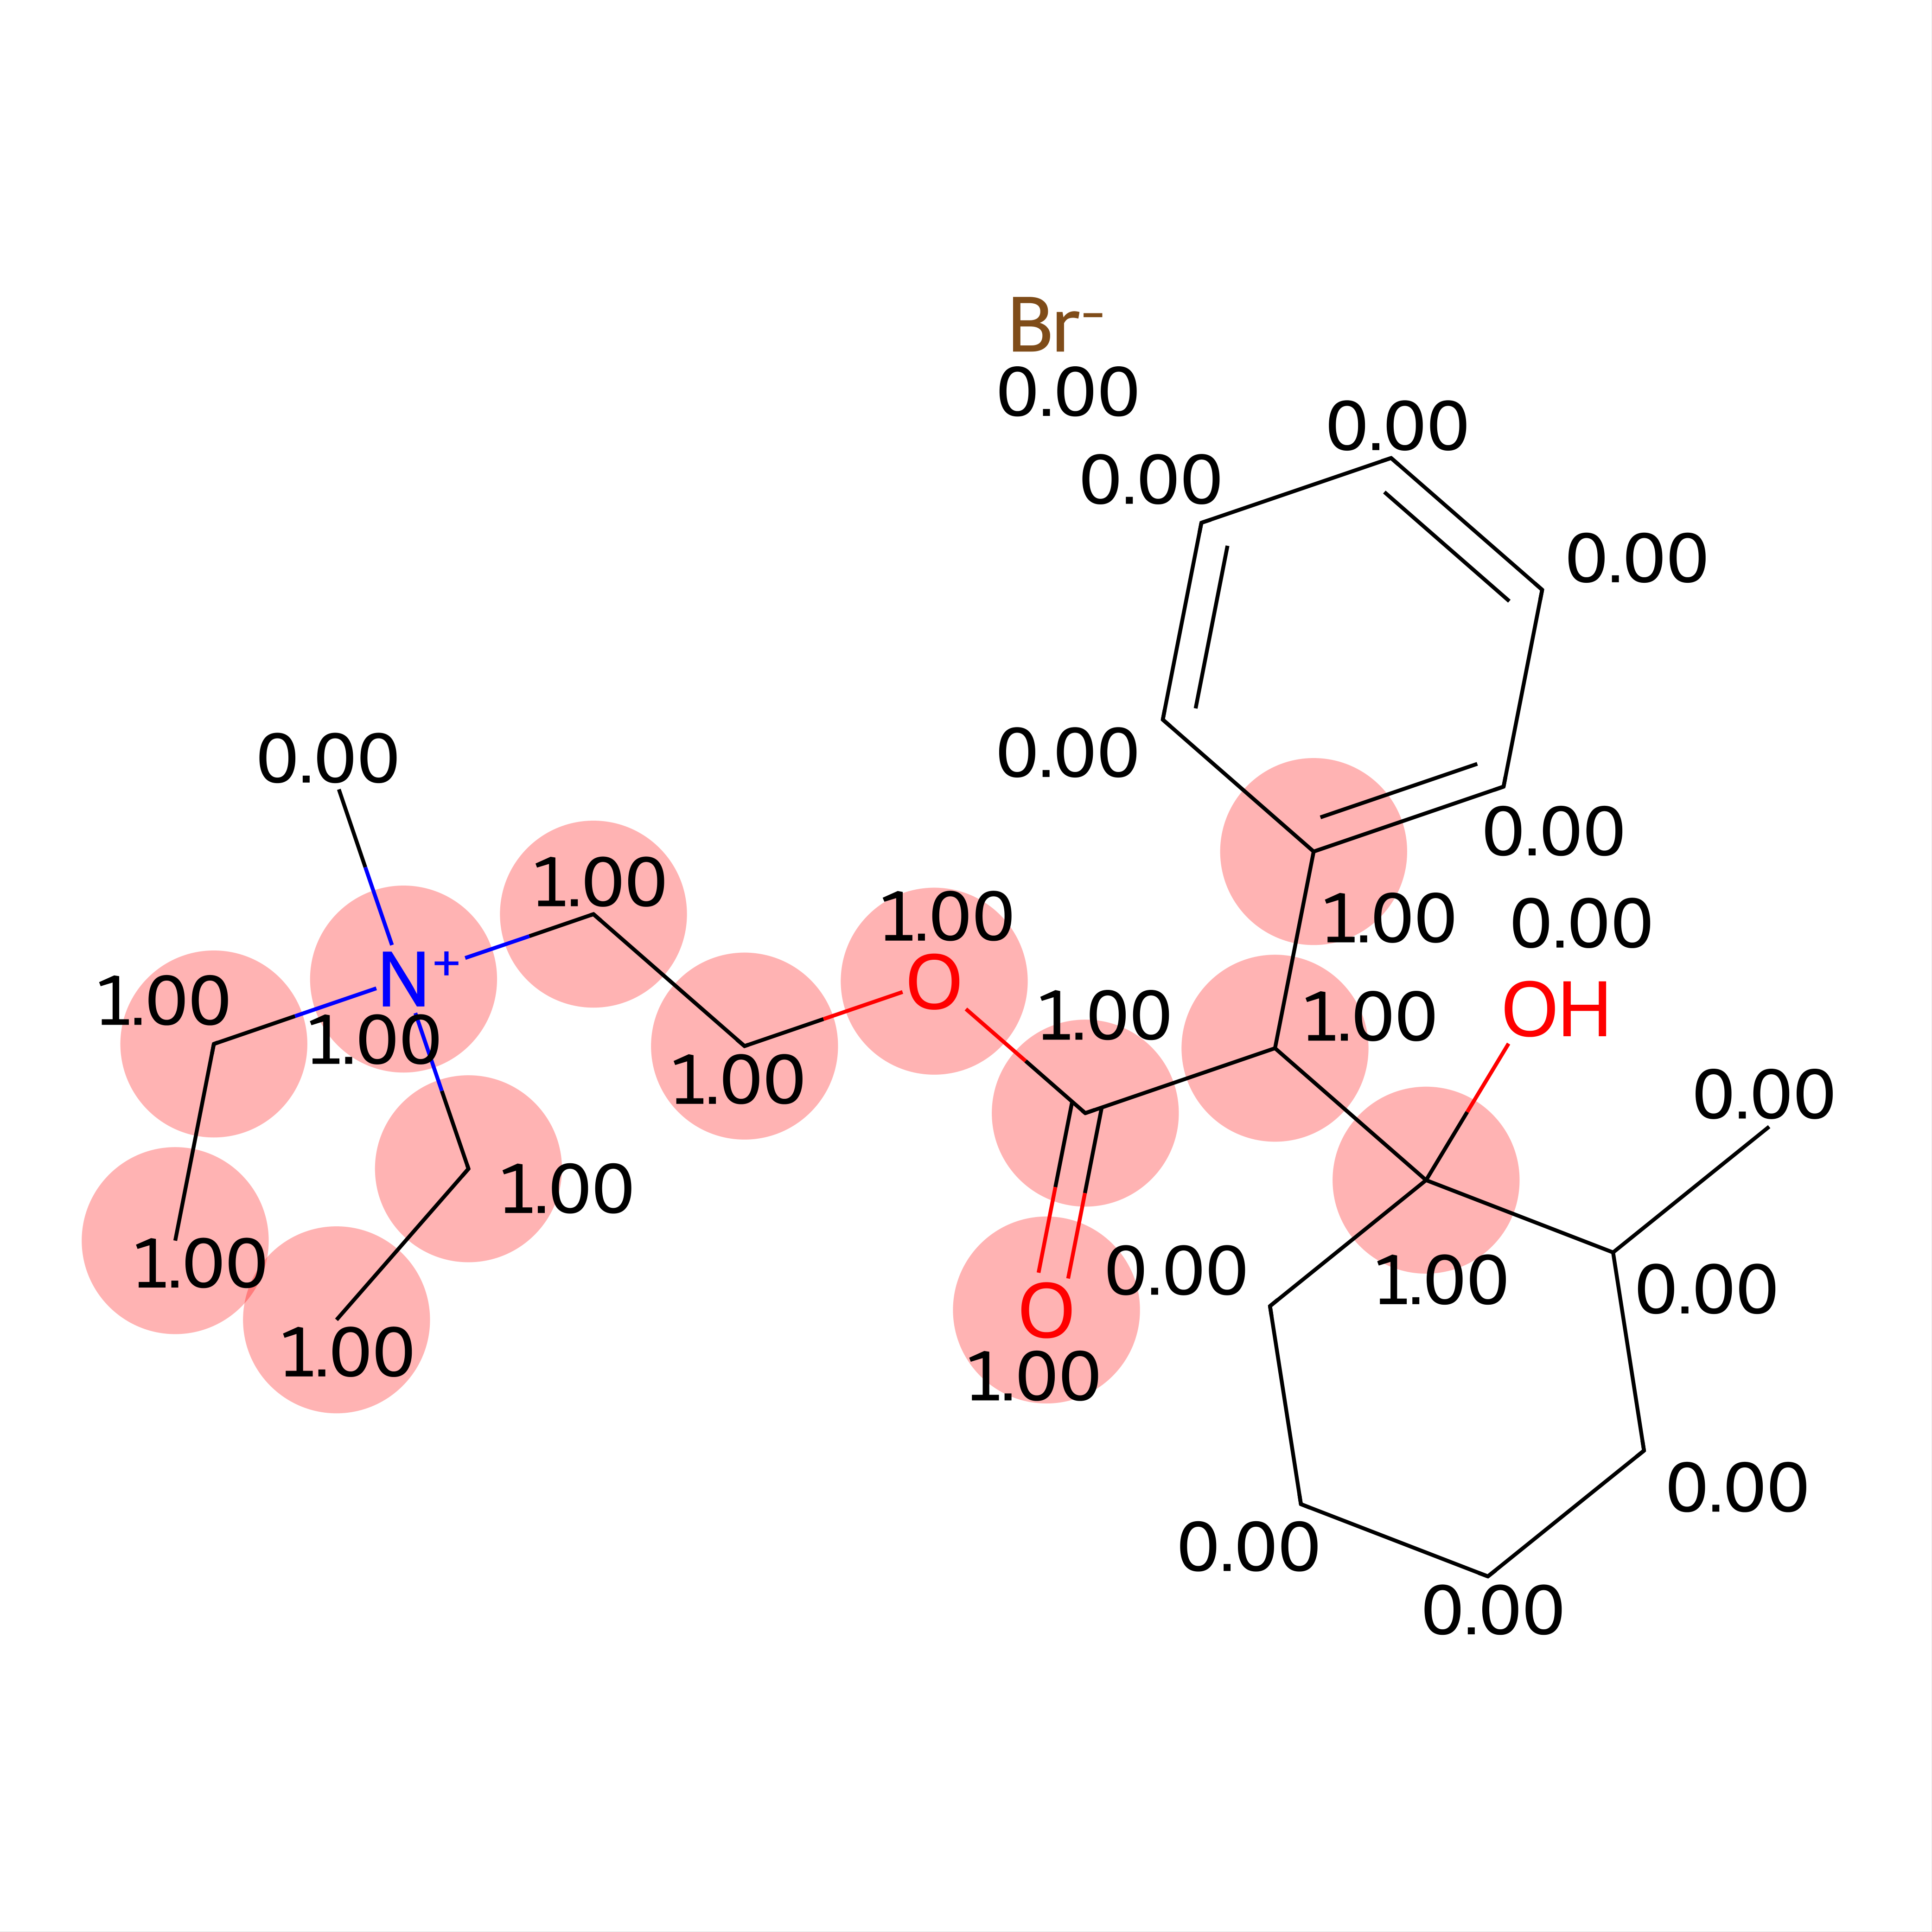

In [8]:
baseline_img = visualize_smarts_match(
    mol,
    smarts_post,
)

baseline_img


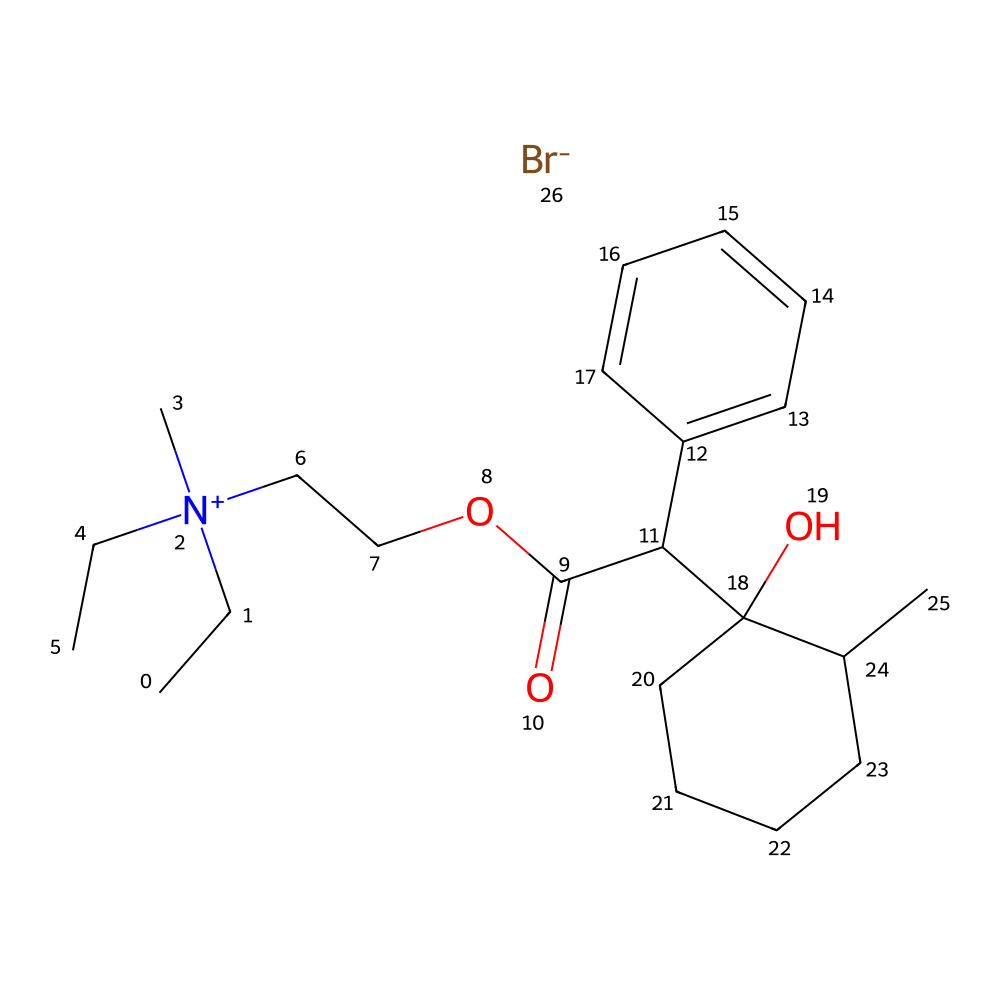

In [9]:
# How does prediction of model change w.r.t to that weird carbon atom?
from rdkit.Chem import Draw

for atom in mol.GetAtoms():
    atom.SetProp('atomNote', f"{atom.GetIdx()}")

Draw.MolToImage(mol, size=(1000, 1000))

In [10]:
PROBLEMATIC_ATOM_IDX = 3

In [11]:
x, edge_index, edge_features = mol_to_torch(mol)
x_paths, e_paths, all_preds, all_activations = get_ig_gradient_paths(
    model=model,
    x=x,
    edge_index=edge_index,
    edge_features=edge_features,
    n_steps=5000
)

x_prim = x.clone()
x_prim[PROBLEMATIC_ATOM_IDX] = torch.zeros_like(x_prim[PROBLEMATIC_ATOM_IDX])

x_prim_paths, e_prim_paths, all_prim_preds, all_activations_prim = get_ig_gradient_paths(
    model=model,
    x=x_prim,
    edge_index=edge_index,
    edge_features=edge_features,
    n_steps=5000
)

In [12]:
critical_points = []

threshold = 0.25
threshold_jump = 0.25

for i, pred in enumerate(all_preds):
    if pred > threshold:
        critical_points.append((threshold, i))
        threshold += threshold_jump

critical_points_prim = []

threshold = 0.25
threshold_jump = 0.25

for i, pred in enumerate(all_prim_preds):
    if pred > threshold:
        critical_points_prim.append((threshold, i))
        threshold += threshold_jump



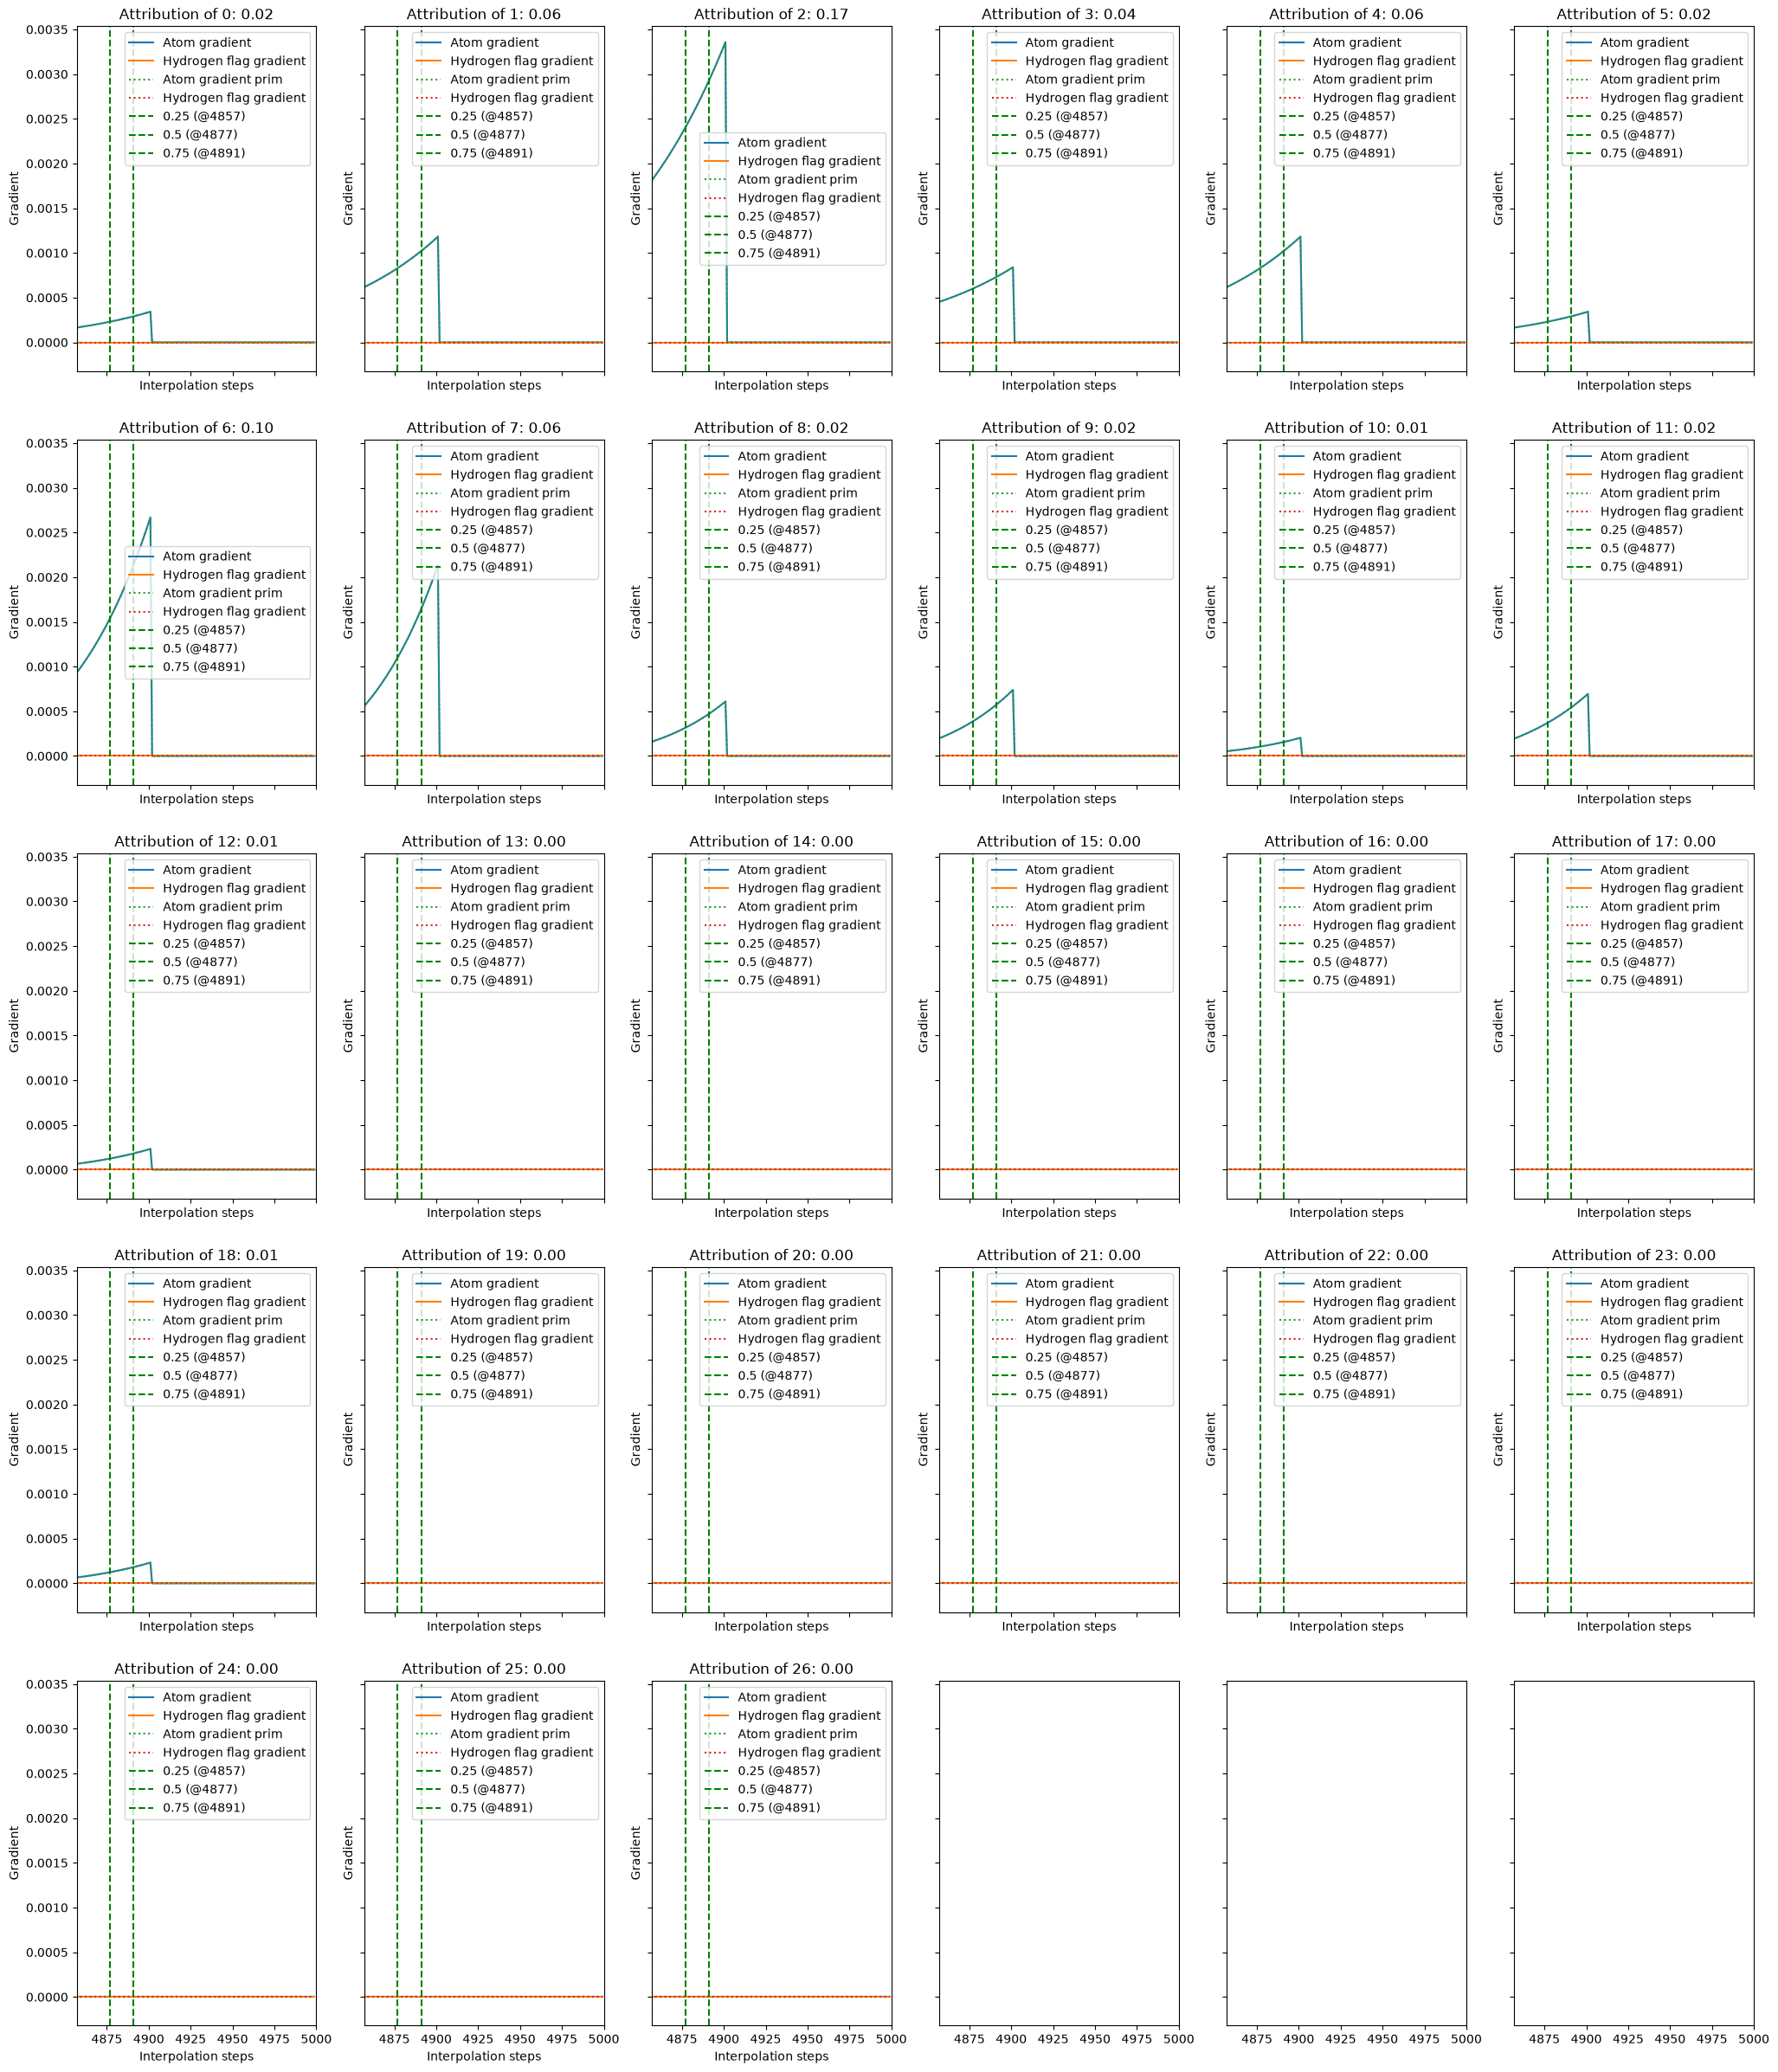

In [13]:
ncols = 5
nrows = (len(x_paths) // ncols) + (1 if len(x_paths) % ncols != 0 else 0)

figs, axs = plt.subplots(
    nrows=ncols,
    ncols=nrows,
    sharex=True,
    sharey=True,
    squeeze=False,
    figsize=(5 * ncols, 5 * nrows)
)

per_atom_attributions = []

xlimit_left = critical_points[0][1]

for atom_idx, ax in zip(range(len(x_paths)), axs.flatten()):
    path = x_paths[atom_idx]
    per_feature_attrs = torch.sum(path, dim=1)
    per_atom_sum = torch.sum(torch.abs(per_feature_attrs))

    ohe_atom_type_plotting = torch.sum(path[:100], dim=0)
    ohe_hydrogens_plotting = torch.sum(path[100:], dim=0)
    ax.plot(ohe_atom_type_plotting.detach().numpy().tolist(), label="Atom gradient")
    ax.plot(ohe_hydrogens_plotting.detach().numpy().tolist(), label="Hydrogen flag gradient")

    path_prim = x_prim_paths[atom_idx]
    ohe_atom_type_plotting_prim = torch.sum(path_prim[:100], dim=0)
    ohe_hydrogens_plotting_prim = torch.sum(path[100:], dim=0)

    ax.plot(ohe_atom_type_plotting.detach().numpy().tolist(), label="Atom gradient prim", linestyle="dotted")
    ax.plot(ohe_hydrogens_plotting_prim.detach().numpy().tolist(), label="Hydrogen flag gradient", linestyle="dotted")

    for (threshold, step) in critical_points:
        ax.axvline(step, label=f"{threshold} (@{step})", color="green", linestyle="dashed")

    ax.set_xlim(xlimit_left, 5000)
    ax.set_title(f"Attribution of {atom_idx}: {per_atom_sum:.2f}")

    ax.set_xlabel("Interpolation steps")
    ax.set_ylabel("Gradient")
    ax.legend()

    per_atom_attributions.append(per_atom_sum.item())

plt.show()

In [14]:
import pandas as pd

# Export CSV of activations of atom 2 (hydrogens, atom ohe) to pandas


path = x_paths[PROBLEMATIC_ATOM_IDX]
per_feature_attrs = torch.sum(path, dim=1)
per_atom_sum = torch.sum(torch.abs(per_feature_attrs))

ohe_atom_type_plotting = torch.sum(path[:100], dim=0)
ohe_hydrogens_plotting = torch.sum(path[100:], dim=0)

list_atom = ohe_atom_type_plotting.detach().numpy().tolist()
list_hydrogen = ohe_hydrogens_plotting.detach().numpy().tolist()

tikz_list_atom = [(i / 5000, atom_grad * 5000) for i, atom_grad in enumerate(list_atom)]
tikz_list_hydrogen = [(i / 5000, hydrogen_grad * 5000) for i, hydrogen_grad in enumerate(list_hydrogen)]

df_atom = pd.DataFrame(tikz_list_atom, columns=["Step", "Atom Gradient"])
df_hydrogen = pd.DataFrame(tikz_list_hydrogen, columns=["Step", "Hydrogen Gradient"])

df_atom.to_csv(f"notebook_artifacts/pattern_4_investigation/atom_{PROBLEMATIC_ATOM_IDX}_feats_gradients.csv",
               index=False)
df_hydrogen.to_csv(
    f"notebook_artifacts/pattern_4_investigation/atom_{PROBLEMATIC_ATOM_IDX}_hydrogen_feats_gradients.csv", index=False)


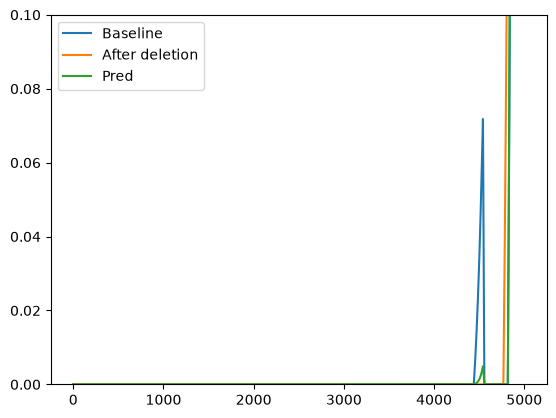

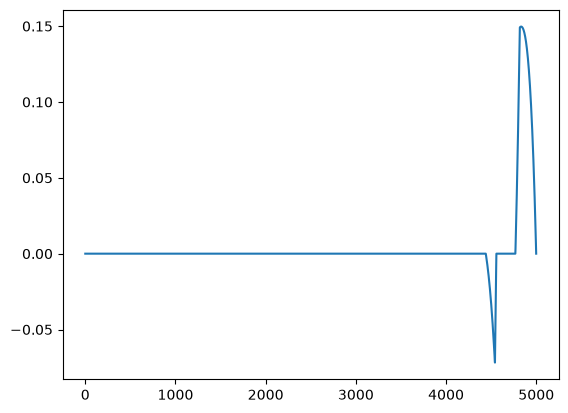

In [15]:
baseline_activations = []
activations_after_deletion = []
diffs = []

investigated_layer_idx = 3
investigated_atom_idx = 7
investigated_feature_idx = 0

for activation, prim_activation in zip(all_activations, all_activations_prim):
    layer_activations = activation[investigated_layer_idx]
    layer_activations_prim = prim_activation[investigated_layer_idx]

    atom_activations = layer_activations[investigated_atom_idx]
    atom_activations_prim = layer_activations_prim[investigated_atom_idx]

    feature = atom_activations[investigated_feature_idx].item()
    feature_val = atom_activations_prim[investigated_feature_idx].item()

    baseline_activations.append(feature)
    activations_after_deletion.append(feature_val)

    diff = feature_val - feature
    diffs.append(diff)

plt.plot(baseline_activations, label="Baseline")
plt.plot(activations_after_deletion, label="After deletion")
plt.plot(all_preds, label="Pred")
plt.ylim(0, 0.1)
plt.legend()
plt.show()
plt.plot(diffs)
plt.show()


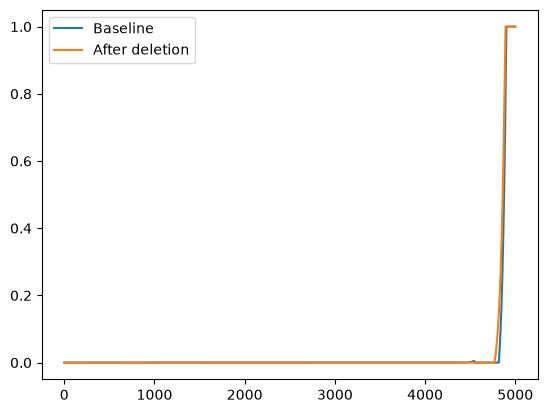

In [16]:
plt.plot(all_preds, label="Baseline")
plt.plot(all_prim_preds, label="After deletion")

plt.legend()
plt.show()

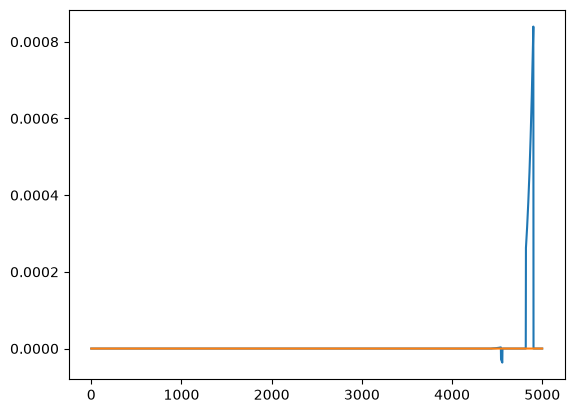

In [17]:
points = []
points_prim = []
path = x_paths[3]
path_prim = x_prim_paths[3]

for step, step_prim in zip(path.T, path_prim.T):
    ohe_atom = step[:100]
    ohe_hydrogen = step[100:]

    sum_atom = torch.sum(ohe_atom)
    sum_hydrogen = torch.sum(ohe_hydrogen)

    ohe_atom_prim = step_prim[:100]
    sum_atom_prim = torch.sum(ohe_atom_prim)

    points.append(sum_atom)
    points_prim.append(sum_atom_prim)

plt.plot(points)
plt.plot(points_prim)
plt.show()

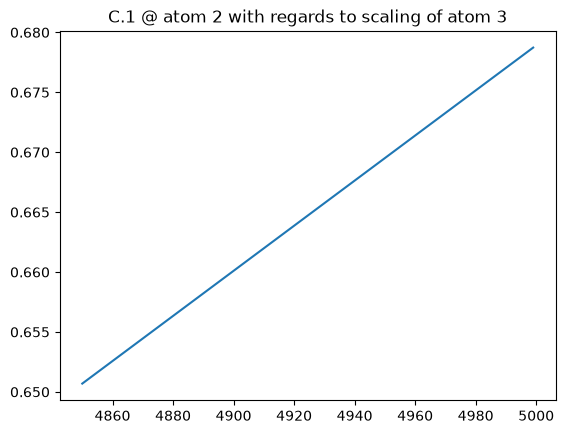

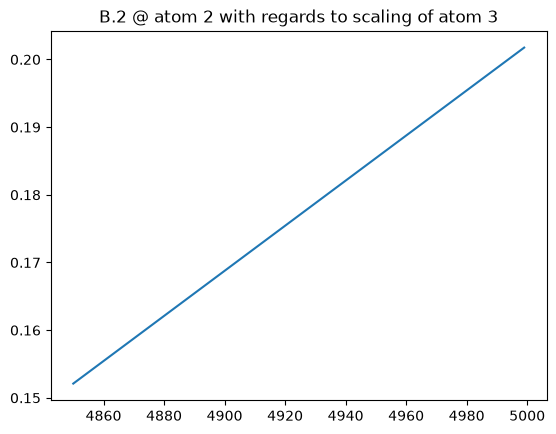

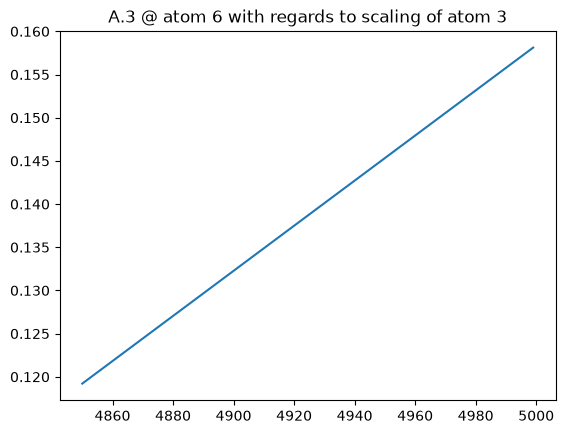

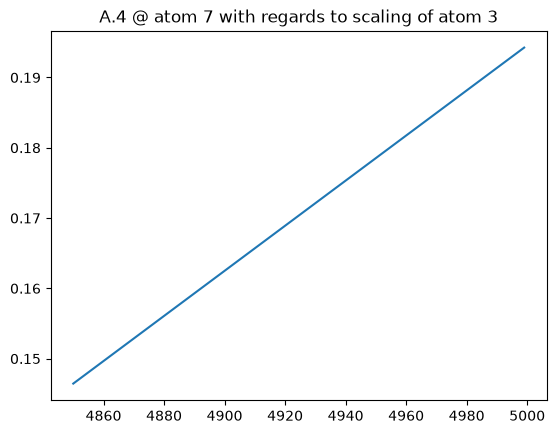

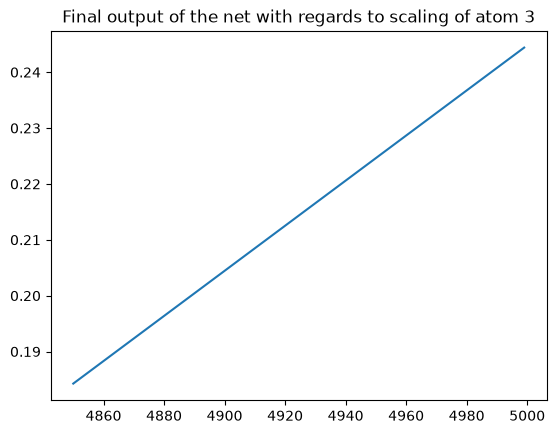

In [22]:
model = MoleculeGDetector()

rising_steps_start = 4850  # Few steps before activation is 0.25
max_steps = 5000
x_scaled = x * (rising_steps_start / max_steps)
e_scaled = edge_features * (rising_steps_start / max_steps)

# We will now continue scaling atom 3, and only atom 3. (it's the troublesome atom)
scaled_atom_idx = PROBLEMATIC_ATOM_IDX

preds = []
special_activations_c_1_2 = []
special_activations_b_2_2 = []
special_activations_a_3_6 = []
special_activations_a_4_7 = []

for step in range(rising_steps_start, max_steps):
    x_scaled[scaled_atom_idx] = x[scaled_atom_idx] * (step / max_steps)
    pred, activations = model(
        x_scaled,
        e_scaled,
        edge_index,
        dump_activations=True
    )

    # Get C.1 @ atom 2
    c_1_2_activation = activations[0][2][2]
    special_activations_c_1_2.append(c_1_2_activation)

    # Get B.2 activation state @ atom 2
    b_2_2_activation = activations[1][2][1]
    special_activations_b_2_2.append(b_2_2_activation)

    # Get A.3 from atom 6
    a_3_6_activation = activations[2][6][0]
    special_activations_a_3_6.append(a_3_6_activation)

    # A.4 from atom 7
    a_4_7_activation = activations[3][7][0]
    special_activations_a_4_7.append(a_4_7_activation)

    preds.append(pred)

plt.plot(list(range(rising_steps_start, max_steps)), special_activations_c_1_2)
plt.title("C.1 @ atom 2 with regards to scaling of atom 3")
plt.show()

plt.plot(list(range(rising_steps_start, max_steps)), special_activations_b_2_2)
plt.title("B.2 @ atom 2 with regards to scaling of atom 3")
plt.show()

plt.plot(list(range(rising_steps_start, max_steps)), special_activations_a_3_6)
plt.title("A.3 @ atom 6 with regards to scaling of atom 3")
plt.show()

plt.plot(list(range(rising_steps_start, max_steps)), special_activations_a_4_7)
plt.title("A.4 @ atom 7 with regards to scaling of atom 3")
plt.show()

plt.plot(list(range(rising_steps_start, max_steps)), preds)
plt.title("Final output of the net with regards to scaling of atom 3")
plt.show()

tikz_list_atom_2_activations = [(i / 5000, activation.item()) for i, activation in
                                enumerate(special_activations_c_1_2, start=4850)]
tikz_list_network_preds = [(i / 5000, pred.item()) for i, pred in enumerate(preds, start=4850)]

df_atom_2_activations = pd.DataFrame(tikz_list_atom_2_activations, columns=['Step', 'Activation'])
df_network_preds = pd.DataFrame(tikz_list_network_preds, columns=['Step', 'Prediction'])

df_atom_2_activations.to_csv(
    f"notebook_artifacts/pattern_4_investigation/atom_2_activations_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}.csv",
    index=False)

df_network_preds.to_csv(
    f"notebook_artifacts/pattern_4_investigation/full_predictions_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}.csv",
    index=False)

tikz_list_c1_2_activations = [(i / 5000, activation.item()) for i, activation in
                              enumerate(special_activations_c_1_2, start=4850)]

tikz_list_b2_2_activations = [(i / 5000, activation.item()) for i, activation in
                              enumerate(special_activations_b_2_2, start=4850)]

tikz_list_a3_6_activations = [(i / 5000, activation.item()) for i, activation in
                              enumerate(special_activations_a_3_6, start=4850)]

tikz_list_a4_7_activations = [(i / 5000, activation.item()) for i, activation in
                              enumerate(special_activations_a_4_7, start=4850)]

df_c1_2_activations = pd.DataFrame(tikz_list_c1_2_activations, columns=['Step', 'Activation'])
df_b2_2_activations = pd.DataFrame(tikz_list_b2_2_activations, columns=['Step', 'Activation'])
df_a3_6_activations = pd.DataFrame(tikz_list_a3_6_activations, columns=['Step', 'Activation'])
df_a4_7_activations = pd.DataFrame(tikz_list_a4_7_activations, columns=['Step', 'Activation'])

df_c1_2_activations.to_csv(
    f"notebook_artifacts/pattern_4_investigation/c12_activations_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}.csv",
    index=False
)

df_b2_2_activations.to_csv(
    f"notebook_artifacts/pattern_4_investigation/b22_activations_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}.csv",
    index=False
)

df_a3_6_activations.to_csv(
    f"notebook_artifacts/pattern_4_investigation/a36_activations_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}.csv",
    index=False
)

df_a4_7_activations.to_csv(
    f"notebook_artifacts/pattern_4_investigation/a47_activations_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}.csv",
    index=False
)


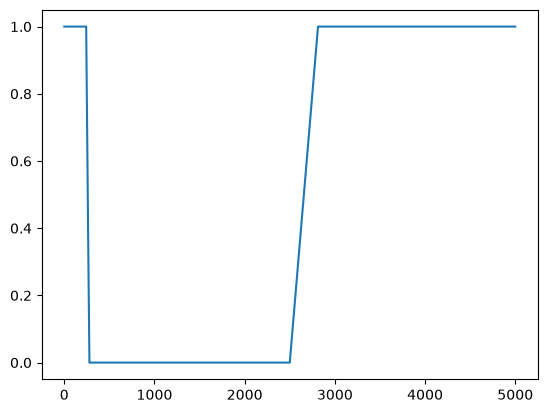

In [19]:
# Check how network's prediction changes when we interpolate atom 2 under r2
model = MoleculeGDetector()
x, edge_index, edge_features = mol_to_torch(mol)

x_mod = x.clone()
x_mod[PROBLEMATIC_ATOM_IDX] = torch.zeros_like(x_mod[PROBLEMATIC_ATOM_IDX])

preds = []

for interpolation_step in range(5000):
    x_mod[PROBLEMATIC_ATOM_IDX] = x[PROBLEMATIC_ATOM_IDX] * (interpolation_step / 5000)

    pred = model(x_mod, edge_features, edge_index)
    preds.append(pred)

plt.plot(preds)

tikz_list_pred_r2 = [(i / 5000, pred.item()) for i, pred in enumerate(preds)]
df_r2 = pd.DataFrame(tikz_list_pred_r2, columns=['Step', 'Prediction'])
df_r2.to_csv(f"notebook_artifacts/pattern_4_investigation/predictions_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}_r2.csv",
             index=False)

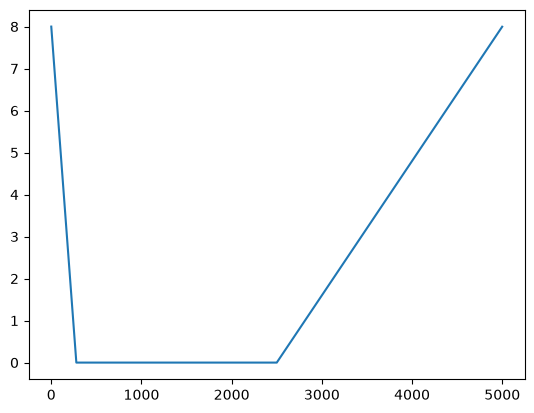

In [20]:
# Check how network's prediction changes when we interpolate atom 2 under r1
model = MoleculeGDetector()
model.readout = AllNonZeroMaxReadout()

x, edge_index, edge_features = mol_to_torch(mol)

x_mod = x.clone()
x_mod[PROBLEMATIC_ATOM_IDX] = torch.zeros_like(x_mod[PROBLEMATIC_ATOM_IDX])

preds = []

for interpolation_step in range(5000):
    x_mod[PROBLEMATIC_ATOM_IDX] = x[PROBLEMATIC_ATOM_IDX] * (interpolation_step / 5000)

    pred = model(x_mod, edge_features, edge_index)
    preds.append(pred)

plt.plot(preds)

tikz_list_pred_r1 = [(i / 5000, pred.item()) for i, pred in enumerate(preds)]
df_r1 = pd.DataFrame(tikz_list_pred_r1, columns=['Step', 'Prediction'])
df_r1.to_csv(f"notebook_artifacts/pattern_4_investigation/predictions_vs_scaling_atom_{PROBLEMATIC_ATOM_IDX}_r1.csv",
             index=False)